In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import pylab as pl

In [2]:
def closest(lat,indlat,lon,indlon):
    loclat=[]
    loclon=[]
    for i in range(len(indlat)):
        loclat.append(np.where(lat>=indlat[i])[0][0])
        loclon.append(np.where(lon<=indlon[i])[0][0])
    return loclat,loclon

#### Load the values

###### Smooth

In [3]:
file='../datafiles/smooth/Shelfwidth.npy'
swArr=np.load(file)

In [4]:
file='../datafiles/smooth/DerivativeOfShelf.npy'
dsArr=np.load(file)

In [5]:
file='../datafiles/smooth/SlopeInclination.npy'
siArr=np.load(file)

In [19]:
file='../datafiles/smooth/PhaseSpeed.npy'
cArr=np.load(file)

In [7]:
file='../datafiles/smooth/Wavelength.npy'
wlArr=np.load(file)

In [8]:
file='../datafiles/smooth/PSD.npy'
PSDArr=np.load(file)


###### Original

In [9]:
file='../datafiles/realistic/Shelfwidth.npy'
swArrOrg=np.load(file)

In [10]:
file='../datafiles/realistic/DerivativeOfShelf.npy'
dsArrOrg=np.load(file)

In [11]:
file='../datafiles/realistic/SlopeInclination.npy'
siArrOrg=np.load(file)


In [20]:
file='../datafiles/realistic/PhaseSpeed.npy'
cArrOrg=np.load(file)

In [13]:
file='../datafiles/realistic/Wavelength.npy'
wlArrOrg=np.load(file)

In [14]:
file='../datafiles/realistic/PSD.npy'
PSDArrOrg=np.load(file)
const=1e7

##### Load coordinates of cities and match with distances here

In [15]:
coast='../datafiles/smooth'
pathVEL=str(coast) + '/WVELAC.nc'
dsVEL= xr.open_dataset(pathVEL)

lat_acVEL=dsVEL.latAC.values
lon_acVEL=dsVEL.lonAC.values

distVEL=dsVEL.dist.values

In [16]:
ind_lon_cities = [ -115.939167, -116.605833, -117.1625]
ind_lat_cities = [ 30.556389, 31.857778, 32.715]

ind_lat,ind_lon=closest(lat_acVEL,ind_lat_cities,lon_acVEL,ind_lon_cities)

#### Plot

In [17]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 5.98),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 1000
plt.rcParams['savefig.dpi'] = 1000

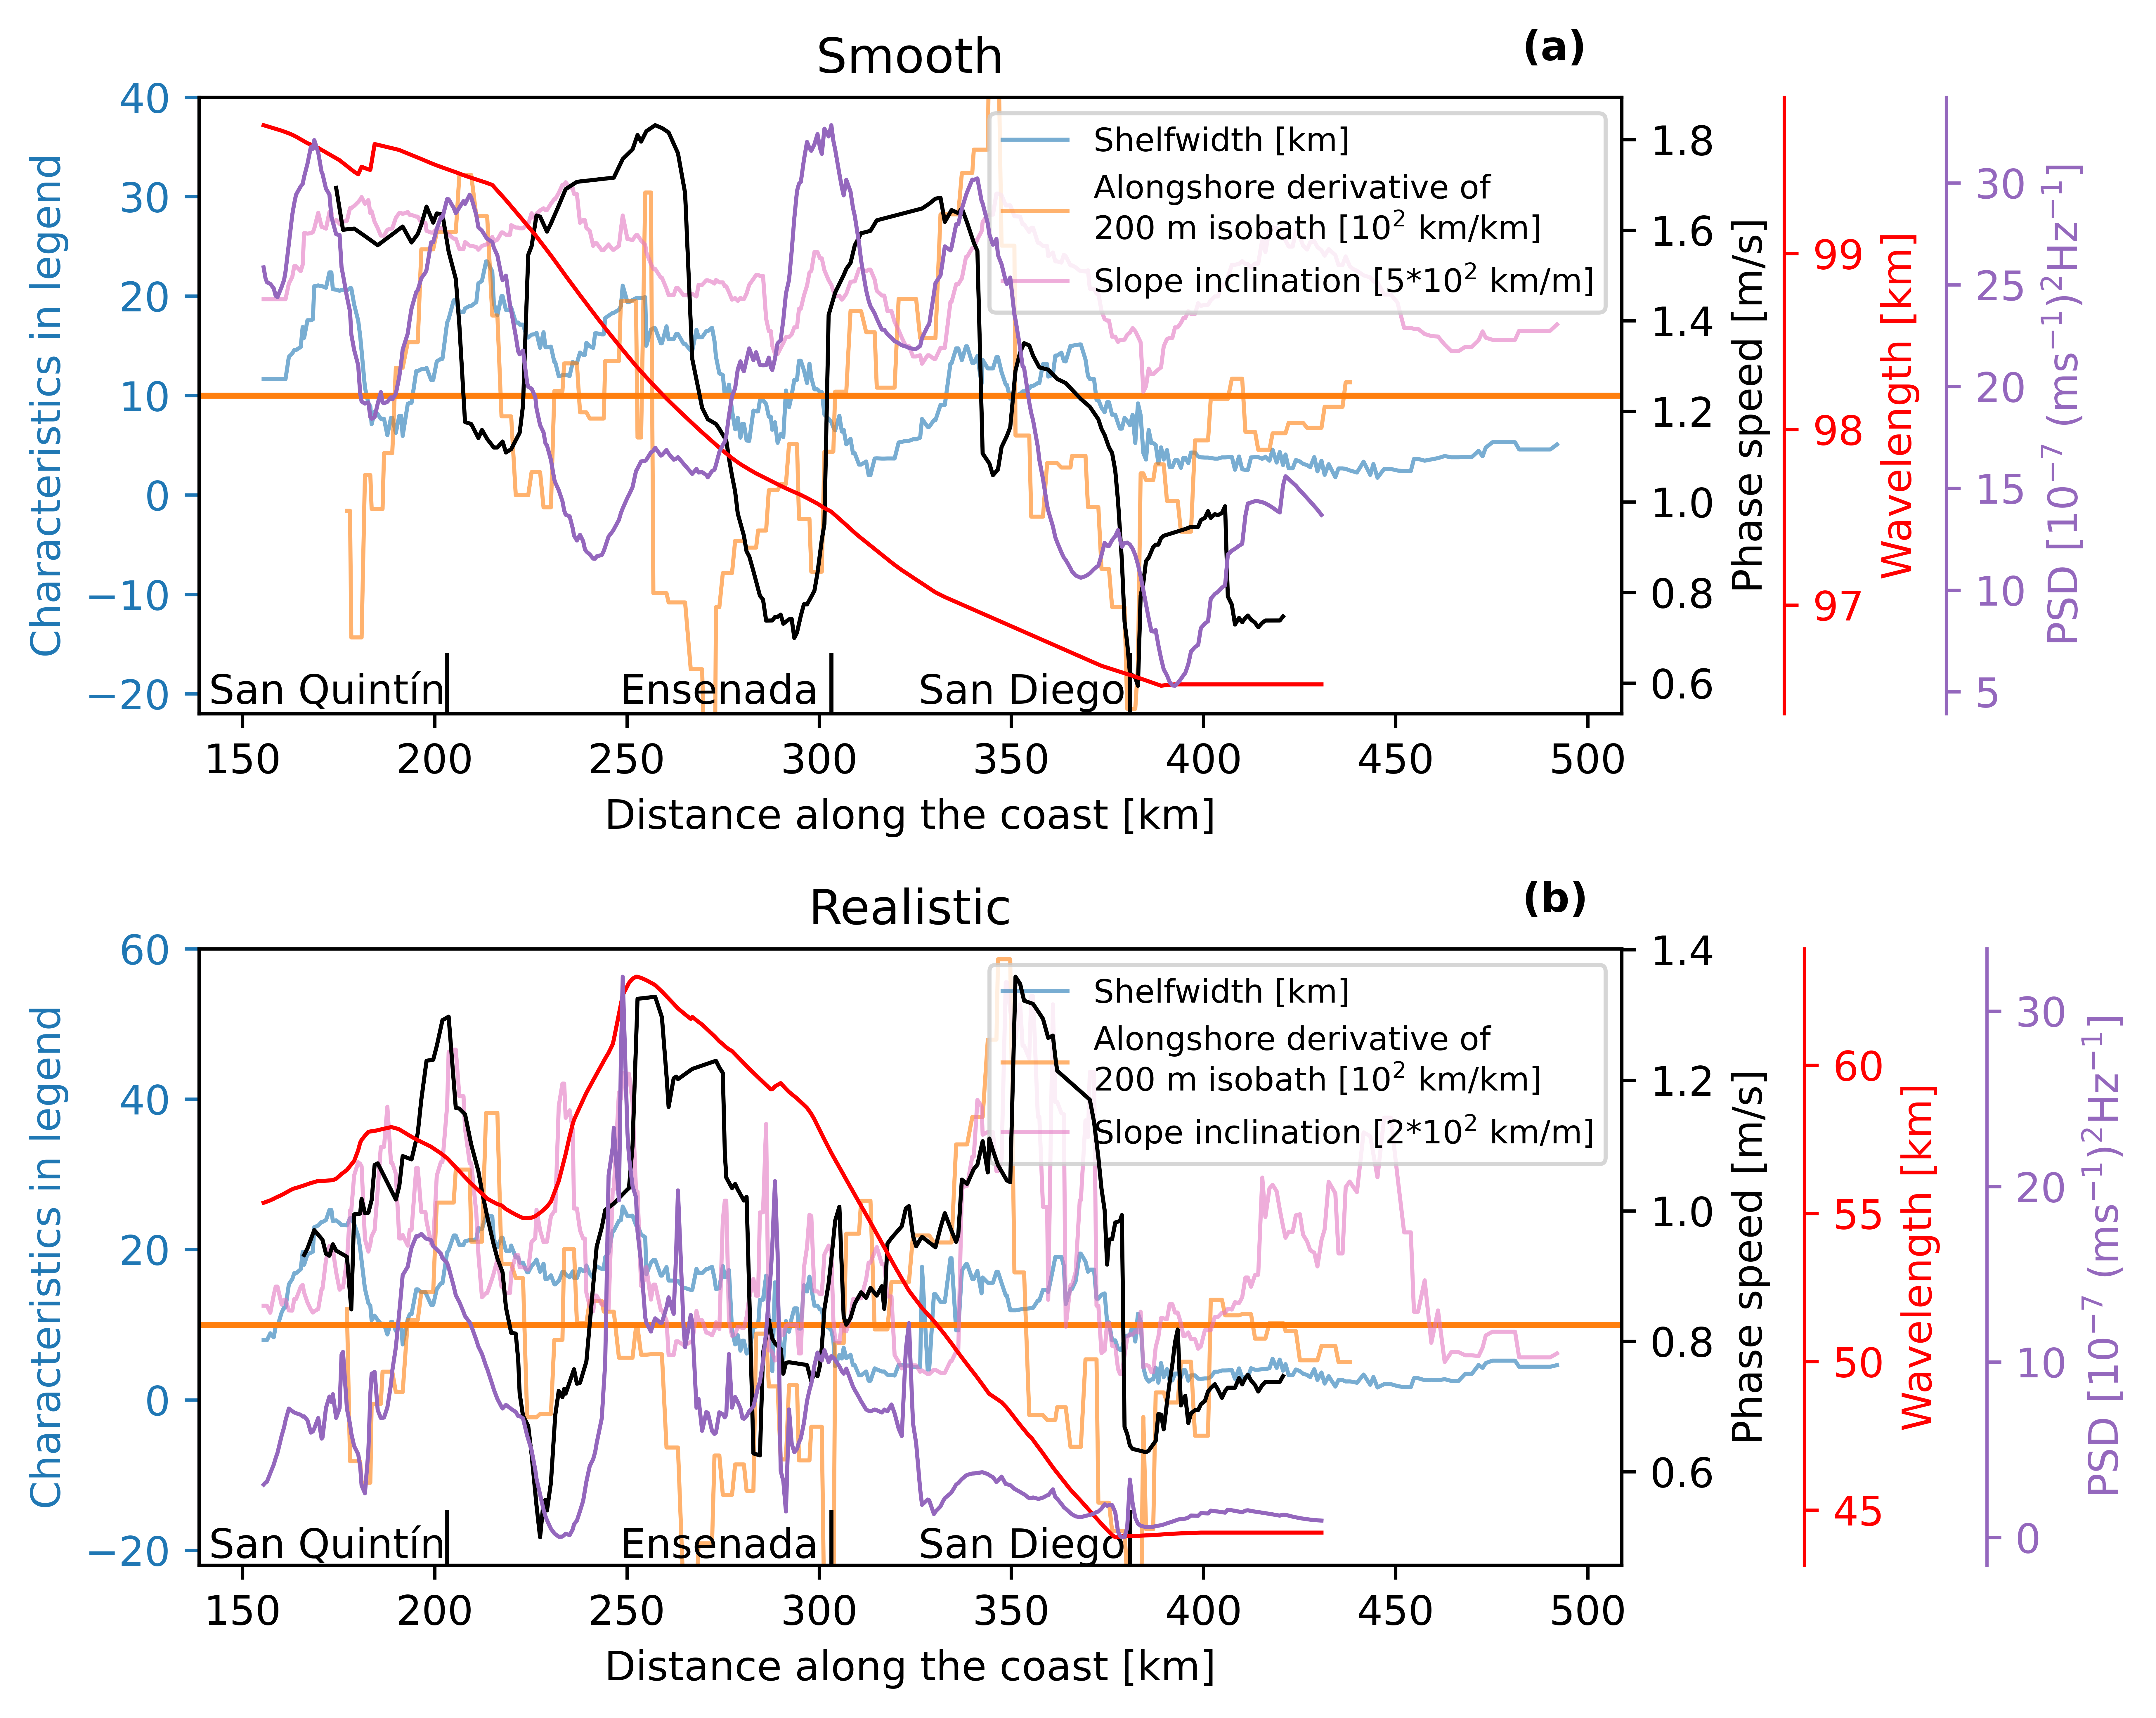

In [21]:
fig,axin2=plt.subplots(2)
ax=axin2[0]

ax.set_title('Smooth')
ax.plot(swArr[:,0],swArr[:,1],'tab:blue',alpha=0.6,label='Shelfwidth [km]',linewidth=1)

ax.plot(dsArr[:,0],dsArr[:,1]*100+10,'tab:orange',alpha=0.6,label='Alongshore derivative of\n200 m isobath [10$^{2}$ km/km]',linewidth=1)
ax.axhline(10,color='tab:orange')

ax.plot(siArr[:,0],siArr[:,1]*500,'tab:pink',alpha=0.6,label='Slope inclination [5*10$^{2}$ km/m]',linewidth=1)

ax.legend(fontsize=8,loc='upper right')
ax.spines['left'].set_color('tab:blue')
ax.set(ylabel='Characteristics in legend',xlabel='Distance along the coast [km]')
ax.yaxis.label.set_color('tab:blue')
ax.tick_params(axis='y', colors='tab:blue')

for ll, lab in zip(ind_lat,
                       ['San Quintín', 'Ensenada', 'San Diego']):
    ax.plot(distVEL[ll],-20,  "|",markersize=20, color='k',zorder=5)
    if lab=='San Quintín':
        ax.text(distVEL[ll]-62,-21,  lab, fontsize=10,color='k')#,rotation=90)
    else:
        ax.text(distVEL[ll]-55,-21,  lab, fontsize=10,color='k')#,rotation=90)

ax.set_ylim((-22,40))
ax1=ax.twinx()
ax1.plot(cArr[:,0],cArr[:,1],'k',linewidth=1)


ax1.spines['right'].set_color('k')
ax1.set(ylabel='Phase speed [m/s]')
ax1.yaxis.label.set_color('k')
ax1.tick_params(axis='y', colors='k')
#ax1.set_ylim(1,1.5)

ax2=ax.twinx()
ax2.spines['right'].set_color('red')
ax2.set(ylabel='Wavelength [km]')
ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='red')
ax2.plot(wlArr[:,0],wlArr[:,1],'red',linewidth=1)

ax2.spines['right'].set_position(('outward', 40))

ax3=ax.twinx()
ax3.spines['right'].set_color('tab:purple')
ax3.set(ylabel='PSD [10$^{-7}$ (ms$^{-1}$)$^{2}$Hz$^{-1}$]')
ax3.yaxis.label.set_color('tab:purple')
ax3.tick_params(axis='y', colors='tab:purple')

ax3.spines['right'].set_position(('outward', 80))
ax3.plot(PSDArr[:,0],PSDArr[:,1]*const,'tab:purple',linewidth=1)


ax.text(0.93, 1.06, '(a)', fontweight='bold', color='k', 
transform=ax.transAxes)

axo=axin2[1]


axo.plot(swArrOrg[:,0],swArrOrg[:,1],'tab:blue',alpha=0.6,label='Shelfwidth [km]',linewidth=1)

axo.set_title('Realistic')

axo.plot(dsArrOrg[:,0],dsArrOrg[:,1]*100+10,'tab:orange',alpha=0.6,label='Alongshore derivative of\n200 m isobath [10$^{2}$ km/km]',linewidth=1)
axo.axhline(10,color='tab:orange')

axo.plot(siArrOrg[:,0],siArrOrg[:,1]*200,'tab:pink',alpha=0.6,label='Slope inclination [2*10$^{2}$ km/m]',linewidth=1)

axo.legend(fontsize=8)

#axo.plot(distVEL[:end+50],OfluxV*1e4+10,'tab:gray')
#axo.plot(distVEL[:end+50],OfluxU*1e4+10,'cyan')


axo.spines['left'].set_color('tab:blue')
axo.set(ylabel='Characteristics in legend',xlabel='Distance along the coast [km]')
axo.yaxis.label.set_color('tab:blue')
axo.tick_params(axis='y', colors='tab:blue')
for ll, lab in zip(ind_lat,
                       ['San Quintín', 'Ensenada', 'San Diego']):
    axo.plot(distVEL[ll],-20,  "|",markersize=20, color='k',zorder=5)
    if lab=='San Quintín':
        axo.text(distVEL[ll]-62,-21,  lab, fontsize=10,color='k')#,rotation=90)
    else:
        axo.text(distVEL[ll]-55,-21,  lab, fontsize=10,color='k')#,rotation=90)

axo.set_ylim((-22,60))
ax1o=axo.twinx()
ax1o.plot(cArrOrg[:,0],cArrOrg[:,1],'k',linewidth=1)


ax1o.spines['right'].set_color('k')
ax1o.set(ylabel='Phase speed [m/s]')
ax1o.yaxis.label.set_color('k')
ax1o.tick_params(axis='y', colors='k')

ax2o=axo.twinx()
ax2o.spines['right'].set_color('red')
ax2o.set(ylabel='Wavelength [km]')
ax2o.yaxis.label.set_color('red')
ax2o.tick_params(axis='y', colors='red')
ax2o.plot(wlArrOrg[:,0],wlArrOrg[:,1],'red',linewidth=1)

ax2o.spines['right'].set_position(('outward', 45))

ax3o=axo.twinx()
ax3o.spines['right'].set_color('tab:purple')
ax3o.set(ylabel='PSD [10$^{-7}$ (ms$^{-1}$)$^{2}$Hz$^{-1}$]')
ax3o.yaxis.label.set_color('tab:purple')
ax3o.tick_params(axis='y', colors='tab:purple')
ax3o.spines['right'].set_position(('outward', 90))
ax3o.plot(PSDArrOrg[:,0],PSDArrOrg[:,1]*const,'tab:purple',linewidth=1)

axo.text(0.93, 1.06, '(b)', fontweight='bold', color='k', 
transform=axo.transAxes)

fig.tight_layout()
plt.savefig('../figures/BATY_fig8.pdf', bbox_inches='tight')